In [1]:
import pandas as pd
df = pd.read_excel('/content/Online Retail_source.xlsx')

# Попередній Data Audit

In [2]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Розмір даних

In [4]:
df.shape

(541909, 8)

Типи колонок

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


NULL у CustomerID

In [6]:
df['CustomerID'].isna().sum()

np.int64(135080)

In [7]:
df[df['CustomerID'].isna()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom


Від’ємні або нульові Quantity

In [8]:
df['Quantity'].min()

-80995

In [9]:
(df['Quantity'] <= 0).sum()

np.int64(10624)

In [10]:
df[df['Quantity'] <= 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


Формат InvoiceDate

In [11]:
df['InvoiceDate'].dtype

dtype('<M8[ns]')

Повні дублікати рядків

In [12]:
df.duplicated().sum()

np.int64(5268)

In [13]:
df[df.duplicated()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


Нульові ціни

In [14]:
df['UnitPrice'].min()

-11062.06

In [15]:
(df['UnitPrice'] <= 0).sum()

np.int64(2517)

Кількість порожніх клітинок

In [16]:
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


# Cleaning-pipeline

Видаляємо рядки без CustomerID

In [17]:
df = df.dropna(subset=['CustomerID'])

Приводимо CustomerID до нормального типу (float to str)

In [18]:
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)

Видаляємо повернення (refund / cancel)

In [19]:
df = df[df['Quantity'] > 0]
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

Видаляємо нульові або від’ємні ціни (тестові або зламані транзакції)

In [20]:
df = df[df['UnitPrice'] > 0]

Видаляємо дублікати

In [21]:
df = df.drop_duplicates()

Створюємо колонку Revenue (потрібна для RFM і churn)

In [22]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

Перевіряємо фінальний стан датасету

In [23]:
df.shape

(392692, 9)

In [24]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,Revenue
count,392692.000000,392692,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,168469.600000
std,180.492832,NaN,22.241836,311.099224


In [25]:
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
Revenue,0


Знаходимо останню дату в даних (важливо для churn!)

In [26]:
snapshot_date = df['InvoiceDate'].max()
snapshot_date

Timestamp('2011-12-09 12:50:00')

# Зведення (Summarization) (Побудова customer-level dataset)

Транзакційний рівень (Transaction-level data) (Один рядок = Одна дія) ---> Клієнтський рівень (Customer-level data) (Один рядок = Один суб’єкт)


*  Іменована агрегація одночасно виконуєте три дії.
*  reset_index() перетворює CustomerID зі статусу індексу (після застосування groupby) на звичайну колонку.
*  Для розрахунку частоти покупок (frequency) рахуємо лише унікальні значення  nunique по номеру чека (InvoiceNo)

In [27]:
import pandas as pd

customer_df = df.groupby('CustomerID').agg(
    first_purchase=('InvoiceDate', 'min'),
    last_purchase=('InvoiceDate', 'max'),
    frequency=('InvoiceNo', 'nunique'),
    monetary=('Revenue', 'sum')
).reset_index()

Рахуємо Recency (скільки днів клієнт не купує, ключова метрика!)

In [29]:
customer_df['recency_days'] = (
    snapshot_date - customer_df['last_purchase']
).dt.days

*   .dt.days перетворює результат (який спочатку є об'єктом «різниця часу») у ціле число днів

In [30]:
df[df.duplicated()].head()
customer_df.head()

,CustomerID,first_purchase,last_purchase,frequency,monetary,recency_days
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,325
1,12347,2010-12-07 14:57:00,2011-12-07 15:52:00,7,4310.00,1
2,12348,2010-12-16 19:09:00,2011-09-25 13:13:00,4,1797.24,74
3,12349,2011-11-21 09:51:00,2011-11-21 09:51:00,1,1757.55,18
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,309


*   розрахунку життєвого циклу клієнта в днях (customer_lifetime_days)
*   розрахунок середнього чека (avg_order_value)



In [31]:
customer_df['customer_lifetime_days'] = (
    customer_df['last_purchase'] - customer_df['first_purchase']
).dt.days

customer_df['avg_order_value'] = (
    customer_df['monetary'] / customer_df['frequency']
)

Якщо є клієнти з нульовою частотою (frequency = 0), розрахунок avg_order_value може призвести до помилки ділення на 0 або появи значень inf. Перевіряємо дані за допомогою методу pandas.DataFrame.describe.

In [32]:
print(customer_df['frequency'].describe())

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: frequency, dtype: float64


Визначаємо бінарний прапорець (Churn flag). Поріг відтоку приймаємо за 180 днів.

In [33]:
CHURN_THRESHOLD = 180

customer_df['churn'] = (
    customer_df['recency_days'] > CHURN_THRESHOLD
).astype(int)

Швидка перевірка

In [34]:
customer_df.head()
customer_df['churn'].value_counts(normalize=True)

,proportion
churn,
0,0.802213
1,0.197787


# RFM-сегментація на основі customer_df

Підготуємо R, F, M показники

In [35]:
rfm = customer_df[['CustomerID', 'recency_days', 'frequency', 'monetary']].copy()

rfm.columns = ['CustomerID', 'R', 'F', 'M']

Перетворимо їх у скорингову шкалу (1–5 квінтилі):
*   R-зворотна шкала, F та M - пряма
*   для F, де часто дуже багато однакових малих значень, використовуємо rank

In [36]:
rfm['R_score'] = pd.qcut(rfm['R'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['F'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['M'], 5, labels=[1,2,3,4,5])

Надаємо RFM-код кожному клієнту

In [37]:
rfm['RFM_score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

Створимо бізнес-сегменти за кодами

In [38]:
def segment(row):
    if row['R_score']=='5' and row['F_score'] in ['4','5']:
        return 'Champions'
    elif row['R_score'] in ['4','5'] and row['F_score'] in ['2','3']:
        return 'Potential Loyalists'
    elif row['R_score'] in ['3','4'] and row['F_score'] in ['4','5']:
        return 'Loyal Customers'
    elif row['R_score']=='5':
        return 'New Customers'
    elif row['R_score'] in ['2','3']:
        return 'At Risk'
    else:
        return 'Lost'

rfm['segment'] = rfm.apply(segment, axis=1)

Подивимось розподіл клієнтів (статистику по категоріях)

In [39]:
rfm['segment'].value_counts()

,count
segment,
Lost,4338


Середній чек для кожного сегмента

In [40]:
rfm.merge(customer_df[['CustomerID','monetary']], on='CustomerID') \
   .groupby('segment')['monetary'] \
   .mean() \
   .sort_values(ascending=False)

,monetary
segment,
Lost,2048.688081


# Retention / Cohort Analysis

Знаходимо місяць покупки

In [41]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

*   Знаходимо місяць першої покупки
*   Присвоюємо когорту кожному ID



In [42]:
cohort = df.groupby('CustomerID')['InvoiceDate'].min().dt.to_period('M')
df['CohortMonth'] = df['CustomerID'].map(cohort)

Знаходимо "стаж" клієнта (CohortIndex)

In [43]:
df['CohortIndex'] = (
    (df['InvoiceMonth'] - df['CohortMonth']).apply(lambda x: x.n)
)

Рахуємо кількість активних клієнтів у кожній когорті

In [44]:
cohort_data = df.groupby(['CohortMonth', 'CohortIndex']) \
                ['CustomerID'].nunique() \
                .reset_index()

Зведена таблиця по когортах (Retention Matrix)

In [45]:
cohort_pivot = cohort_data.pivot_table(
    index='CohortMonth',
    columns='CohortIndex',
    values='CustomerID'
)

Перетворюємо у відсотки утримання (Retention Rate)

In [46]:
cohort_size = cohort_pivot.iloc[:, 0]

retention = cohort_pivot.divide(cohort_size, axis=0)

In [47]:
retention.round(3).head()

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,1.0,0.366,0.323,0.384,0.363,0.398,0.363,0.349,0.354,0.395,0.374,0.503,0.266
2011-01,1.0,0.221,0.266,0.230,0.321,0.288,0.247,0.242,0.300,0.326,0.365,0.118,NaN
2011-02,1.0,0.187,0.187,0.284,0.271,0.247,0.253,0.279,0.247,0.305,0.068,NaN,NaN
2011-03,1.0,0.150,0.252,0.199,0.223,0.168,0.268,0.230,0.279,0.086,NaN,NaN,NaN
2011-04,1.0,0.213,0.203,0.210,0.197,0.227,0.217,0.260,0.073,NaN,NaN,NaN,NaN


Візуалізація тепловою картою

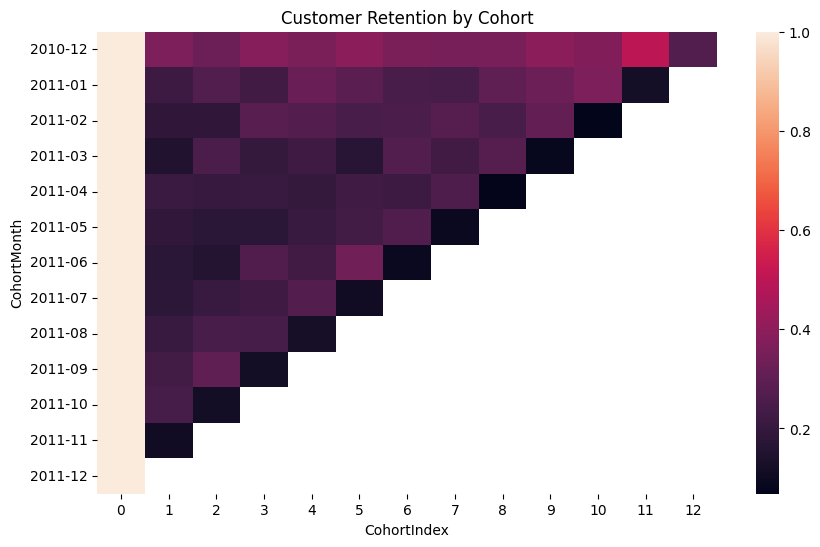

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(retention, annot=False)
plt.title('Customer Retention by Cohort')
plt.show()

# Correlation Analysis

*   готуємо датасет
*   будуємо кореляційну  матрицю
*   візуалізуємо

In [49]:
analysis_df = customer_df[['recency_days',
                           'frequency',
                           'monetary',
                           'avg_order_value',
                           'customer_lifetime_days',
                           'churn']].copy()

In [50]:
analysis_df.corr(numeric_only=True)

,recency_days,frequency,monetary,avg_order_value,customer_lifetime_days,churn
recency_days,1.000000,-0.260578,-0.121831,-0.000115,-0.513562,0.877797
frequency,-0.260578,1.000000,0.552780,0.019130,0.476560,-0.178597
monetary,-0.121831,0.552780,1.000000,0.393667,0.225374,-0.077524
avg_order_value,-0.000115,0.019130,0.393667,1.000000,0.008490,0.004968
customer_lifetime_days,-0.513562,0.476560,0.225374,0.008490,1.000000,-0.415911
churn,0.877797,-0.178597,-0.077524,0.004968,-0.415911,1.000000


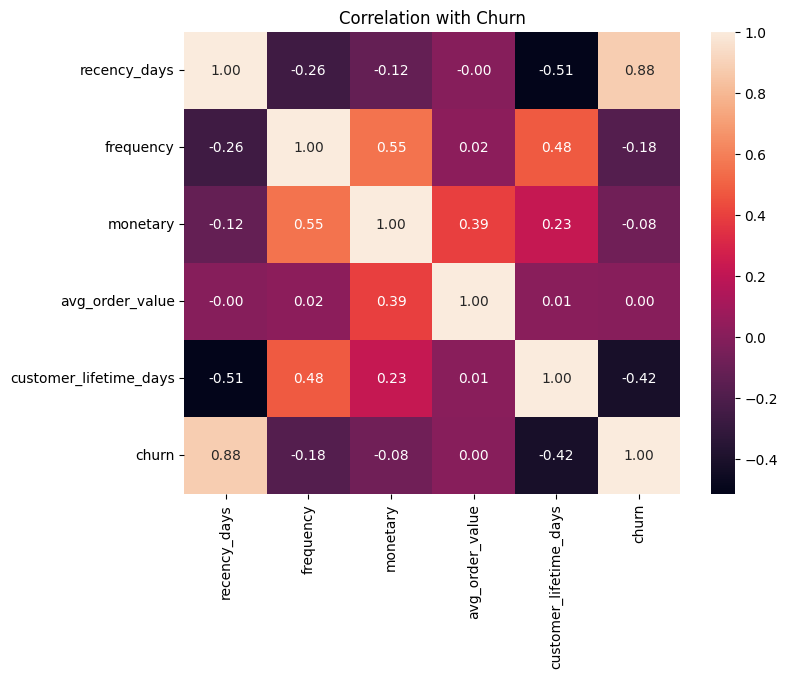

In [51]:
plt.figure(figsize=(8,6))
sns.heatmap(analysis_df.corr(numeric_only=True),
            annot=True,
            fmt=".2f")
plt.title('Correlation with Churn')
plt.show()



*   середні значення для активних (0) та втрачених клієнтів (1)
*   візуалізація розподілу



In [52]:
analysis_df.groupby('churn').mean()

,recency_days,frequency,monetary,avg_order_value,customer_lifetime_days
churn,,,,,
0,47.949138,4.954598,2394.522986,413.214255,157.713793
1,268.324009,1.503497,646.001050,435.619570,19.862471


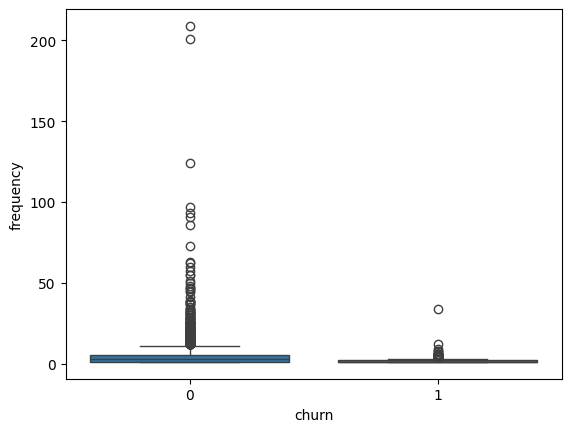

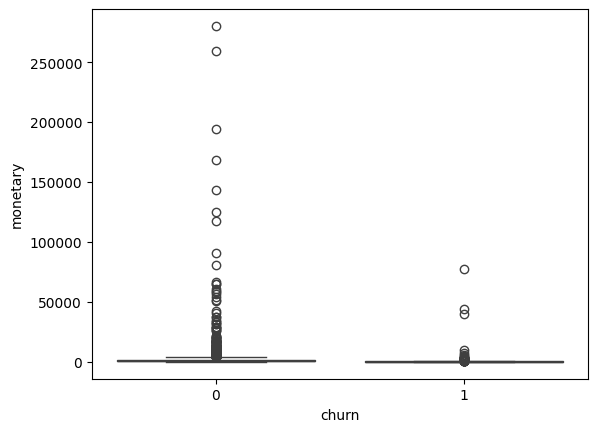

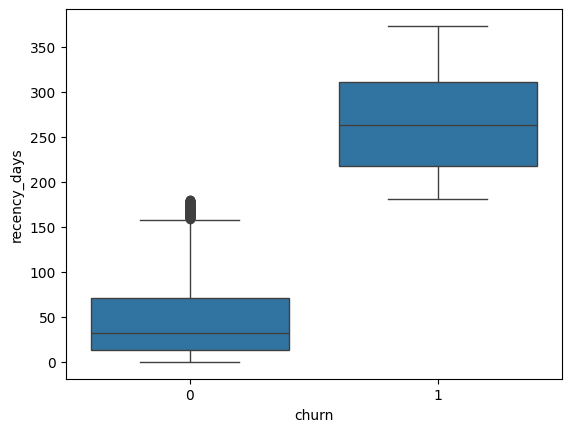

In [53]:
sns.boxplot(data=analysis_df, x='churn', y='frequency')
plt.show()

sns.boxplot(data=analysis_df, x='churn', y='monetary')
plt.show()

sns.boxplot(data=analysis_df, x='churn', y='recency_days')
plt.show()

# Predictive Churn Modeling

Беремо тільки поведінкові змінні (без дат і ID)

In [54]:
model_df = customer_df[['recency_days',
                        'frequency',
                        'monetary',
                        'avg_order_value',
                        'customer_lifetime_days',
                        'churn']].copy()

Розділяємо дані на X (фактори) і y (ціль)

In [55]:
X = model_df.drop('churn', axis=1)
y = model_df['churn']

Розподіл на тренувальну на тестову вибірки.

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

Приводимо дані до одного масштабу.

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Будуємо Logistic Regression

In [58]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

Робимо прогноз

In [59]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

Оцінюємо якість моделі

Оцінюємо якість моделі

In [60]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
roc_auc_score(y_test, y_prob)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1054
           1       1.00      1.00      1.00       248

    accuracy                           1.00      1302
   macro avg       1.00      1.00      1.00      1302
weighted avg       1.00      1.00      1.00      1302



np.float64(0.9999693946256963)

Дивимось, що найбільше впливає на churn

In [61]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Impact': model.coef_[0]
}).sort_values(by='Impact', key=abs, ascending=False)

coefficients

,Feature,Impact
0,recency_days,8.606546
1,frequency,0.395907
4,customer_lifetime_days,-0.244899
3,avg_order_value,-0.067365
2,monetary,-0.014067
